## **Задание 1 - неявный метод Эйлера**

В случае неявного метода Эйлера заданное дифференциальное уравнение будет выглядкть следующим образом:  $$u_{n+1}=u_n+ dt \lambda u_{n+1}$$ откуда находим $$u_{n+1}=\dfrac{u_n}{1- dt \lambda}$$

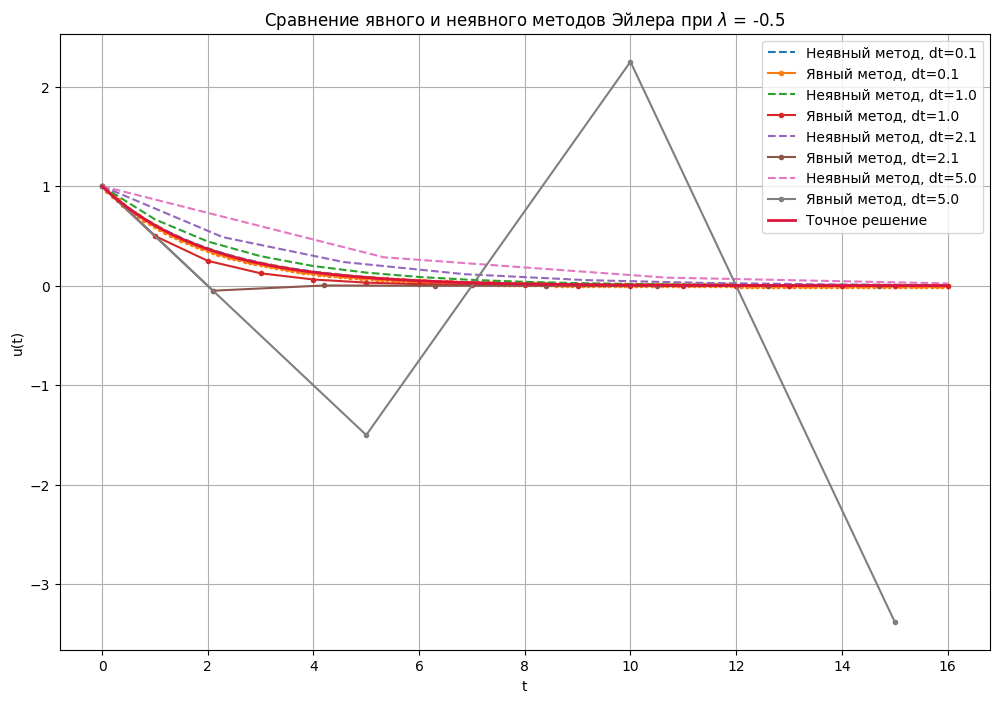

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def exp_euler_solve(lam, u0, T, dt):
    """Решает $du/dt = \lambda u$ на $0 < t < T$ с $u(t=0) = u0$ при помощи явного метода Эйлера."""
    num_steps = int(T/dt)
    tt = np.arange(num_steps+1)*dt
    y = np.empty(num_steps+1)

    # Начальное условие
    y[0] = u0
    
    for k in range(num_steps):
        y[k+1] = y[k] + dt*lam*y[k]
    return tt, y

def imp_euler_solve(lam, u0, T, dt):
    """Решает du/dt = lambda u на 0 < t < T с u(t=0) = u0 при помощи неявного метода Эйлера."""
    num_steps = int(T / dt)
    tt = np.linspace(0, T, num_steps + 1)
    y = np.zeros(num_steps + 1)

    # Начальное условие
    y[0] = u0

    for n in range(num_steps):
        y[n+1] = y[n] / (1 - lam * dt)
    
    return tt, y

# Тестирование
lam = -0.5 
tt, y = imp_euler_solve(lam, u0=1.0, T=8/abs(lam), dt=2.1/abs(lam))

assert (y > 0).all()


# Отрисовка
lam = -0.5
u0 = 1.0
T = abs(int(8 / lam))

# Шаги по времени
dts = [0.1, 1.0, 2.1, 5.0]

plt.figure(figsize=(12, 8))

for dt in dts:
    tt_imp, u_imp = imp_euler_solve(lam, u0, T, dt)
    tt_exp, u_exp = exp_euler_solve(lam, u0, T, dt)

    plt.plot(tt_imp, u_imp, '--', label=f'Неявный метод, dt={dt}')
    plt.plot(tt_exp, u_exp, '.-', label=f'Явный метод, dt={dt}')

# Точное решение (благо диффур простой)
tt_exact = np.linspace(0, T, 100)
u_exact = np.exp(lam * tt_exact)
plt.plot(tt_exact, u_exact, '-', lw=2, label='Точное решение', color = 'crimson')

plt.xlabel('t')
plt.ylabel('u(t)')
plt.title(r'Сравнение явного и неявного методов Эйлера при $\lambda$ = -0.5')
plt.legend()
plt.grid(True)
plt.show()

Видим, что при $\lambda \tau > 1$ явное решение сильно отклоняется от точного решения 'вниз', а также не имеет некоторых свойств точного решения (например, видно что решение, полученное явным методом в этом случае не является монотонно убывающим, в отличие от точного решения). При этом для слишком большого шага по времени ($dt = 5$) начинаются огромные осцилляции решения.

Для неявного метода же таких особенностей не наблюдается: даже при $\lambda \tau > 2$ приближённое решение близко (насколько это позволяет шаг по времени) к точному. Это значит, что неявная схема Эйлера устойчивей явной.

## **Задание 2 - сравнение явной схемы Эйлера и матричной экспоненты**

In [2]:
from scipy.linalg import expm

def euler_solve2(a, u0, T, dt):
    """Solve the system du/dt = Au via an explicit Euler scheme.
    
    Parameters
    ----------
    a : ndarray, shape(ndim, ndim)
        The matrix of the l.h.s.
    u0 : ndarray, shape(ndim,)
        Initial condition
    T : float
        Construct the solution for t ∈ [0, T)
    dt : float
        Integration step size τ
        
    Returns
    -------
    t : ndarray, shape (n,)
        Integration times
    y : ndarray, shape (n, ndim)
        Solution of the FD system. 
        y[k, :] is the solution at t[k].
    """
    a = np.asarray(a, dtype=float)
    u0 = np.asarray(u0, dtype=float)
    num_steps = int(T / dt)
    tt = np.arange(num_steps + 1) * dt
    ndim = a.shape[0]
    
    y = np.zeros((num_steps + 1, ndim))

    # Начальное условие
    y[0] = u0
    
    for k in range(num_steps):
        y[k + 1] = y[k] + dt * a @ y[k]
    
    return tt, y

def mat_exp_solve(a, u0, tt):
    """Construct the solution of du/dt = A u with u(0) = u0 at times `tt`.
    
    Parameters
    ----------
    a : ndarray, shape (ndim, ndim)
        The matrix A.
    u0 : ndarray, shape (ndim,)
        Initial condition.
    tt : ndarray, shape (n,)
        The values of t.
        
    Returns
    -------
    u : ndarray, shape (n, ndim)
        u[k, :] is the solution at t[k].
    """
    
    u = np.zeros((len(tt), len(u0)))
    for i, t in enumerate(tt):
        u[i] = expm(a * t) @ u0
    
    return u

Сравним решения:

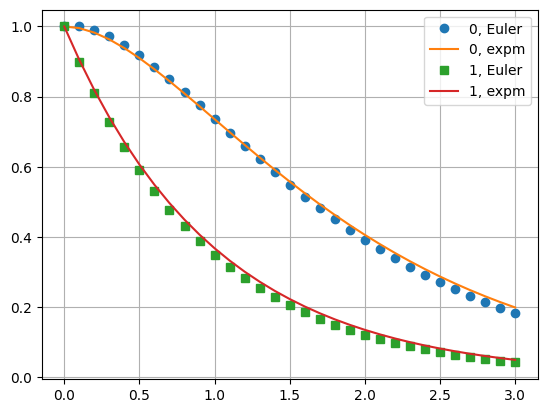

In [3]:
a = np.array([[-1, 1],
              [0, -1]], dtype=float)
t, y  = euler_solve2(a, u0=[1, 1], T=3, dt=0.1)
ym = mat_exp_solve(a, [1, 1], t)
x_ex = (t+1)*np.exp(-t)
y_ex = np.exp(-t)

plt.plot(t, y[:, 0], 'o', label='0, Euler')
plt.plot(t, ym[:, 0], '-', label='0, expm')

plt.plot(t, y[:, 1], 's', label='1, Euler')
plt.plot(t, ym[:, 1], '-', label='1, expm')

plt.legend(loc='best')
plt.grid(True)

Видим небольшие отклонения решения, полученного явным методом эйлера от точного (полученного с помощью матричной экспоненты)

## **Задание 3 - проверка жёсткости системы и неявные методы**

In [4]:
A = np.array([[-10, 10],[32, -499]])

eig = np.linalg.eigvals(A)
print(eig)

[  -9.34647667 -499.65352333]


Такие собственные значения удовлетворяют всем трём условиям жёсткости системы.

Решаем систему:

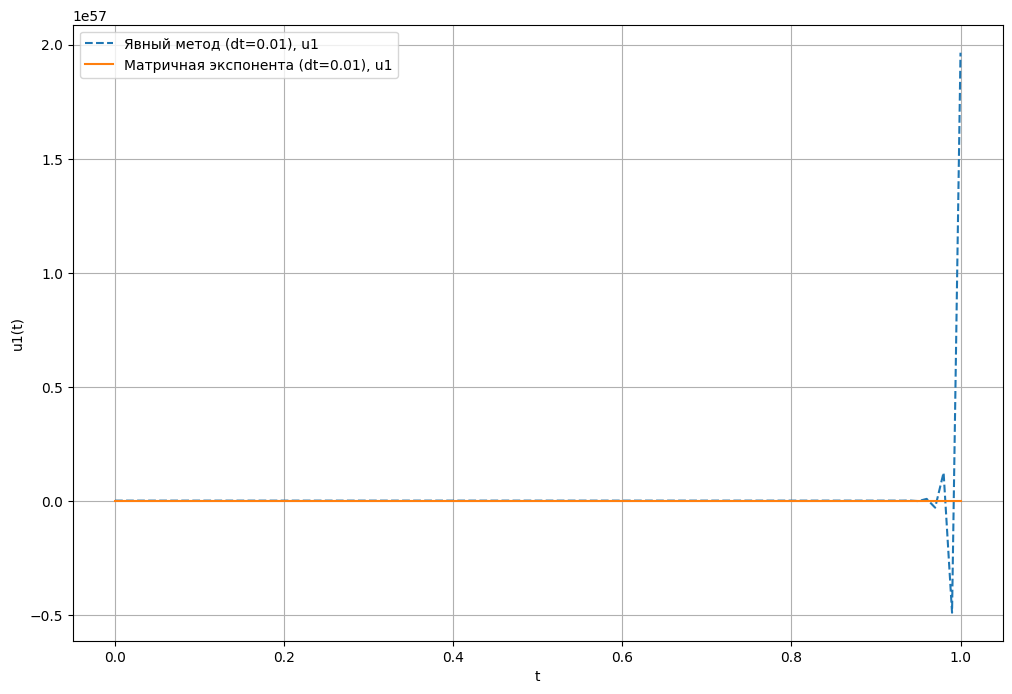

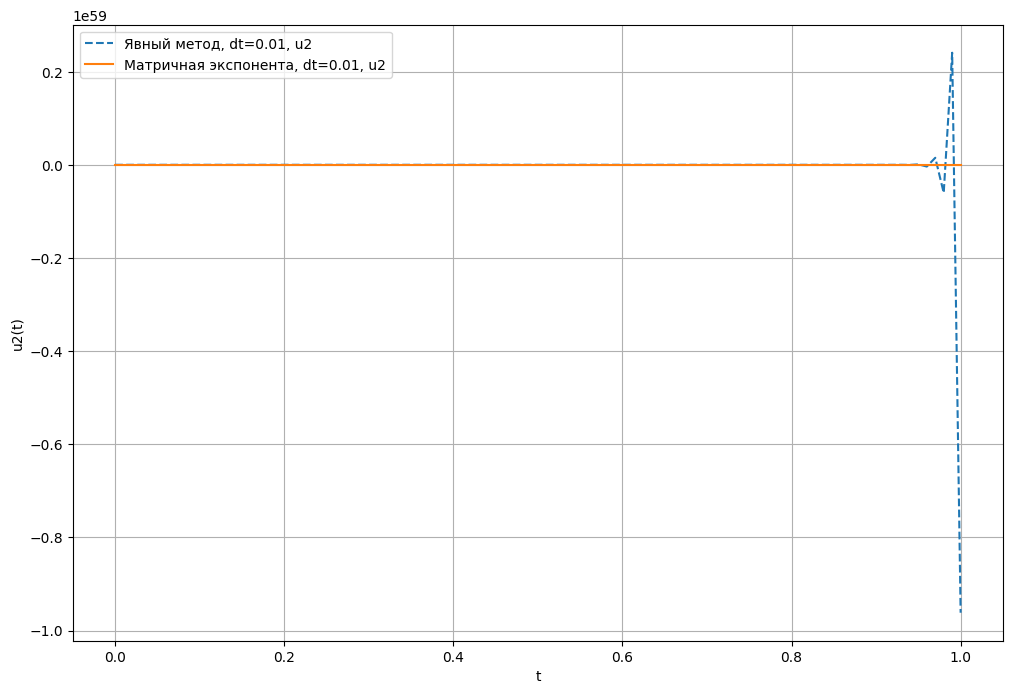

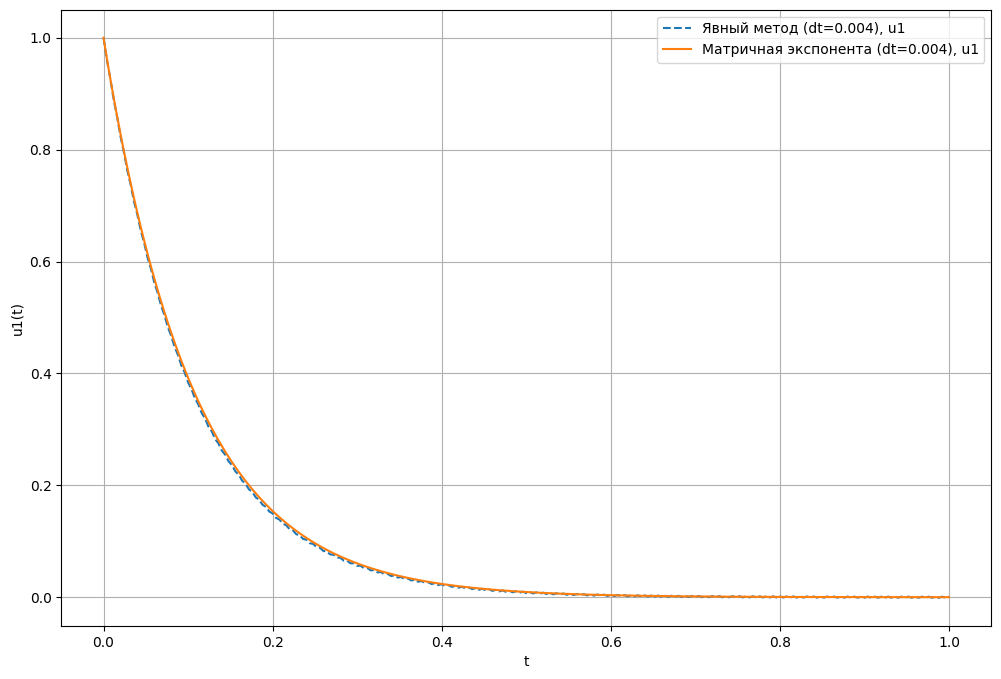

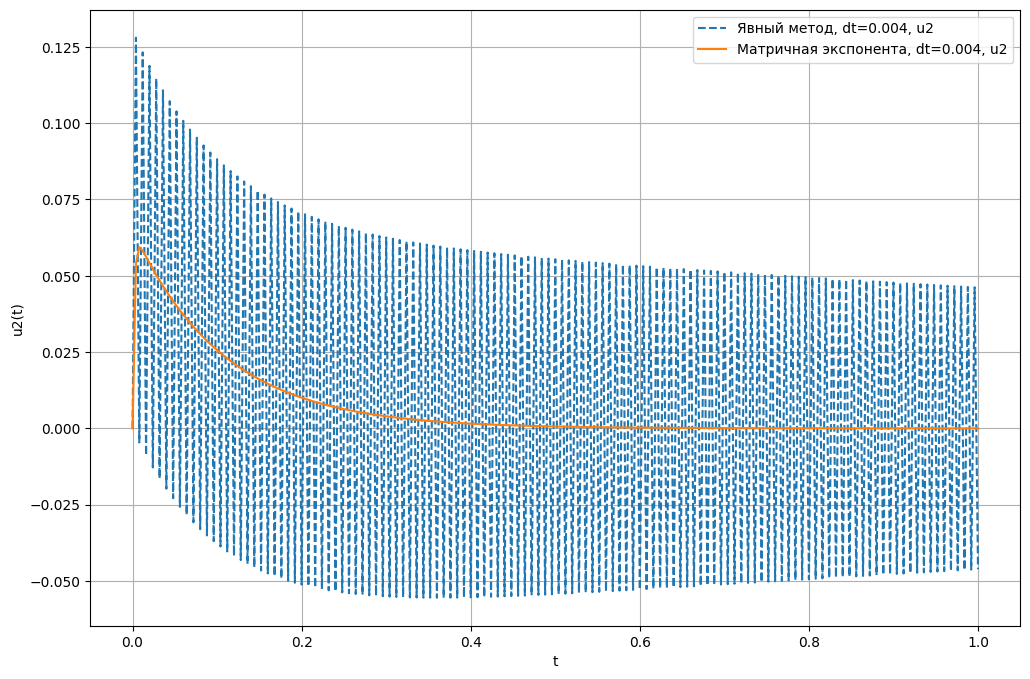

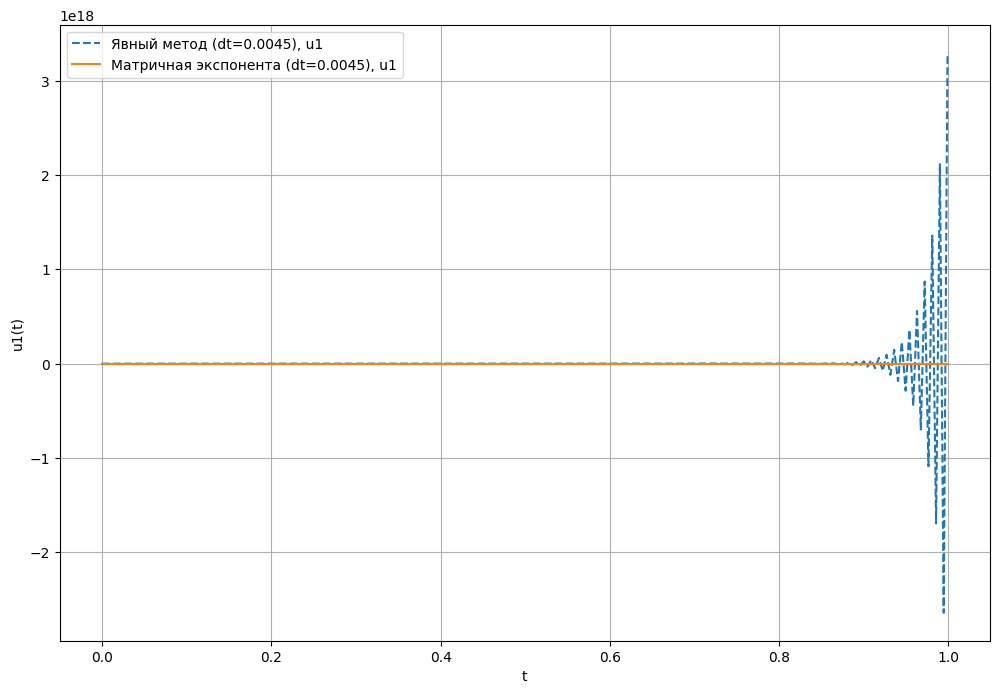

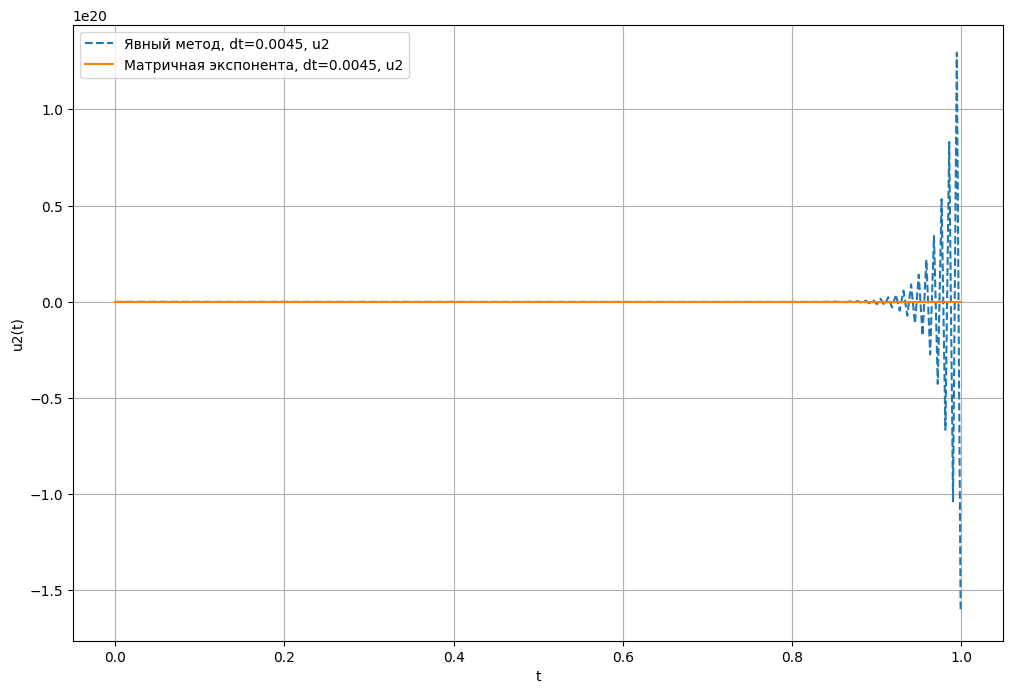

In [5]:
u0 = np.array([1, 0])
T = 1
dts = [0.01,0.004, 0.0045]

# Графики
for dt in dts:
    plt.figure(figsize=(12, 8))
    t, y = euler_solve2(A, u0, T, dt)
    ym = mat_exp_solve(A, u0, t)
    plt.plot(t, y[:, 0], '--', label=f'Явный метод (dt={dt}), u1')
    plt.plot(t, ym[:, 0], '-', label=f'Матричная экспонента (dt={dt}), u1')
    plt.xlabel('t')
    plt.ylabel('u1(t)')
    plt.legend()
    plt.grid(True)
    plt.show()
    plt.figure(figsize=(12, 8))
    plt.plot(t, y[:, 1], '--', label=f'Явный метод, dt={dt}, u2')
    plt.plot(t, ym[:, 1], '-', label=f'Матричная экспонента, dt={dt}, u2')
    plt.xlabel('t')
    plt.ylabel('u2(t)')
    plt.legend()
    plt.grid(True)
    plt.show()

Видим, что в абсолютном большинстве случаем численное решение улетает в область больших значений. Лишь при одном значении временного шага одна из двух координат оказалась близка к точному решению.

Используем теперь неявный метод Эйлера:

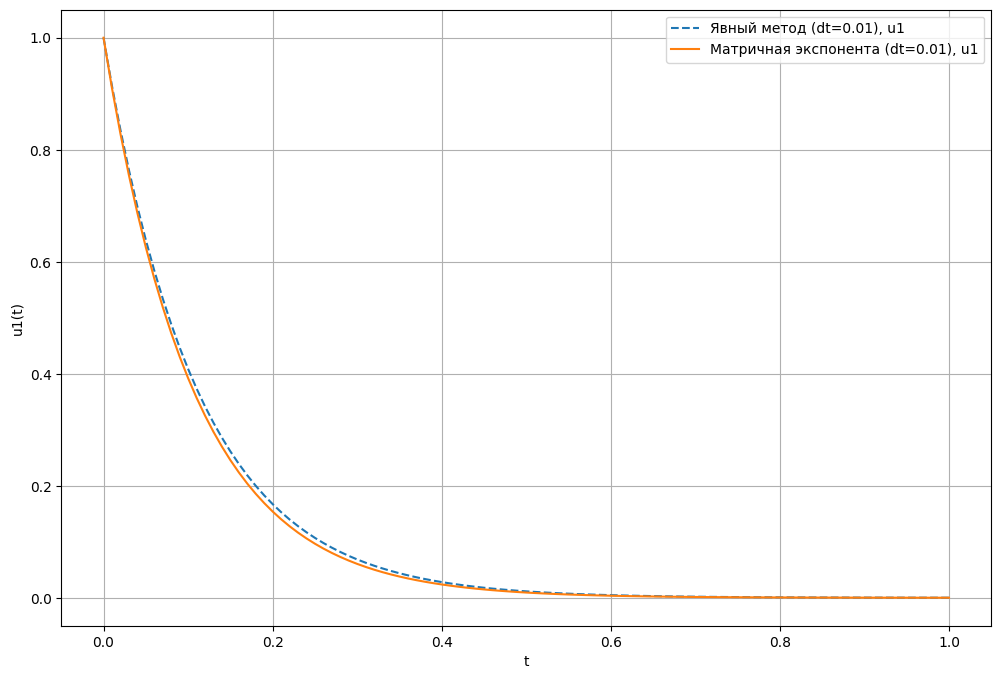

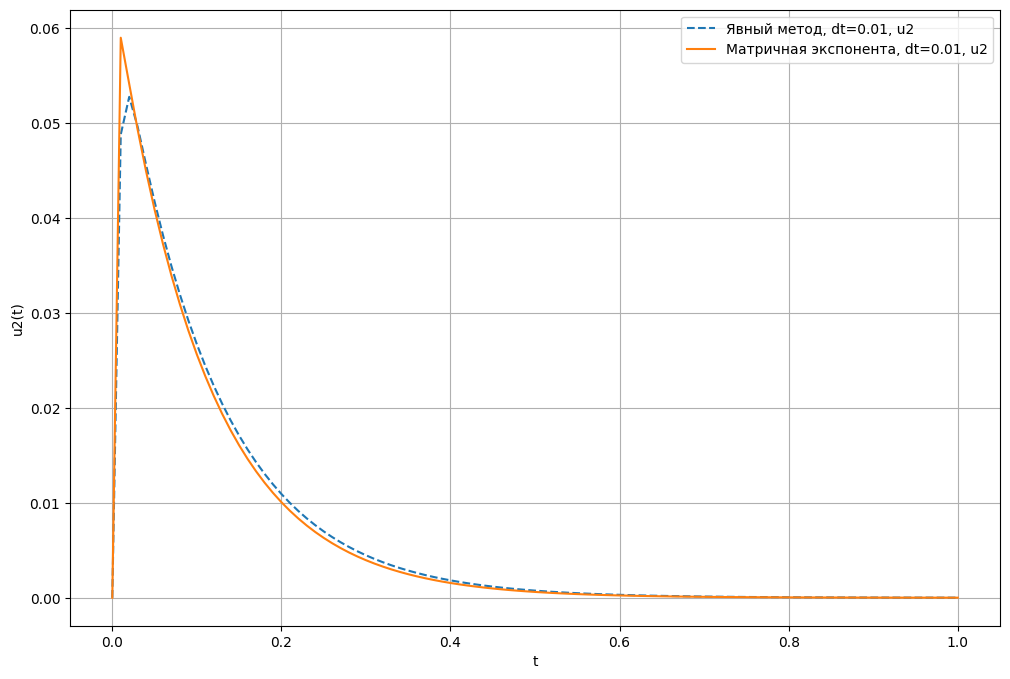

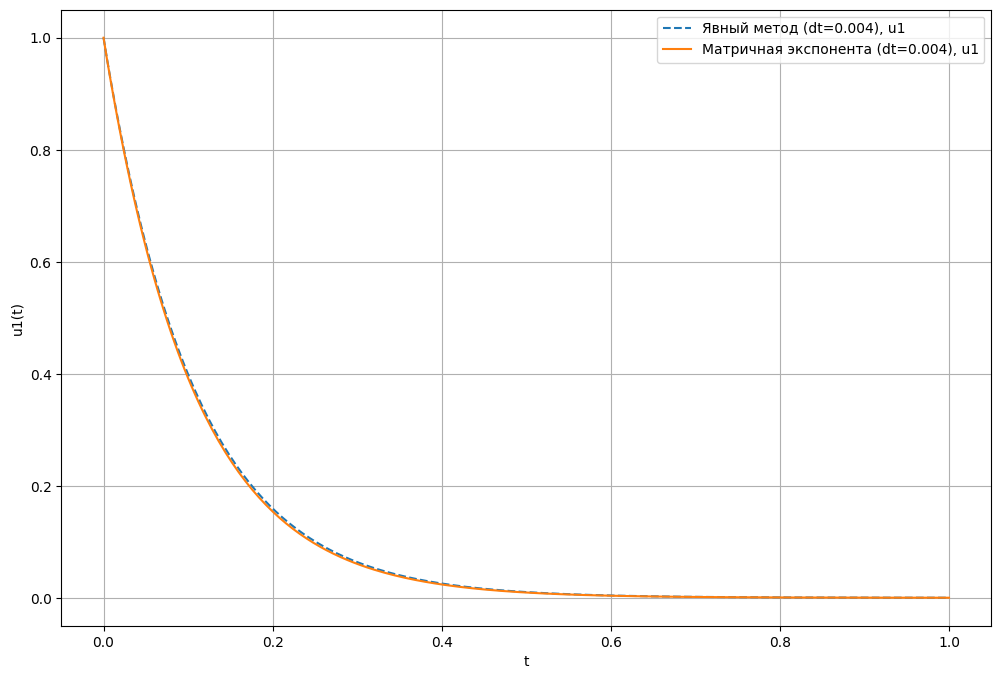

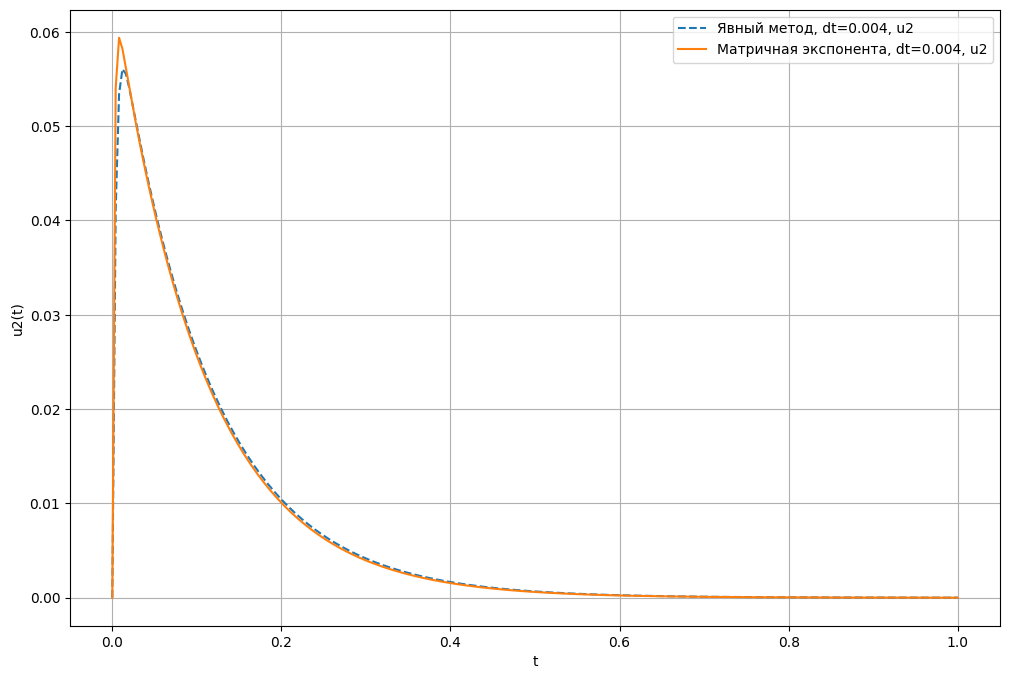

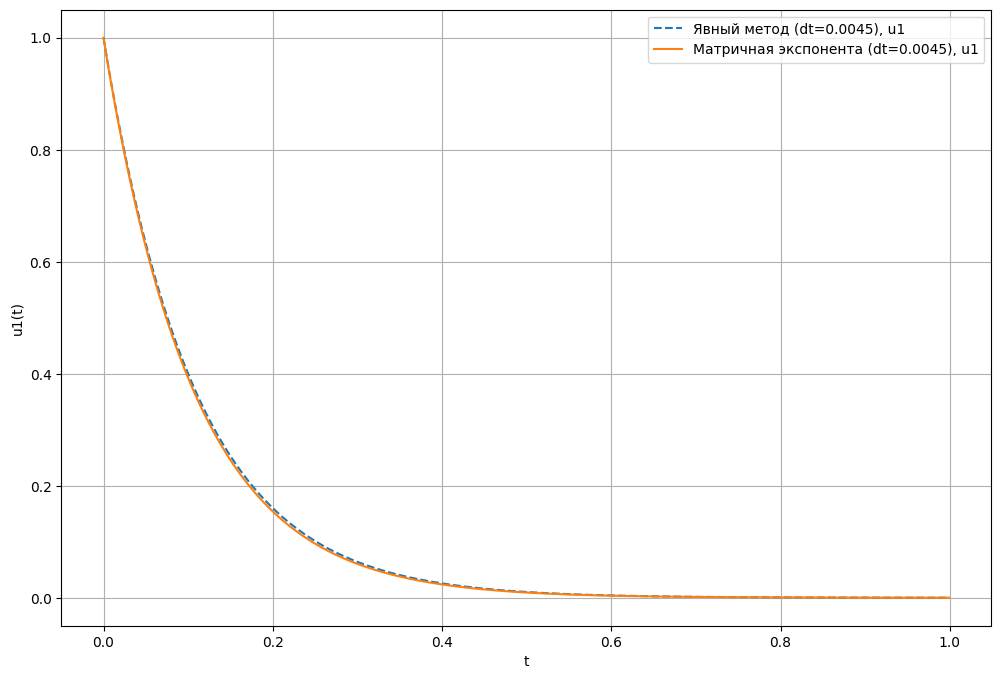

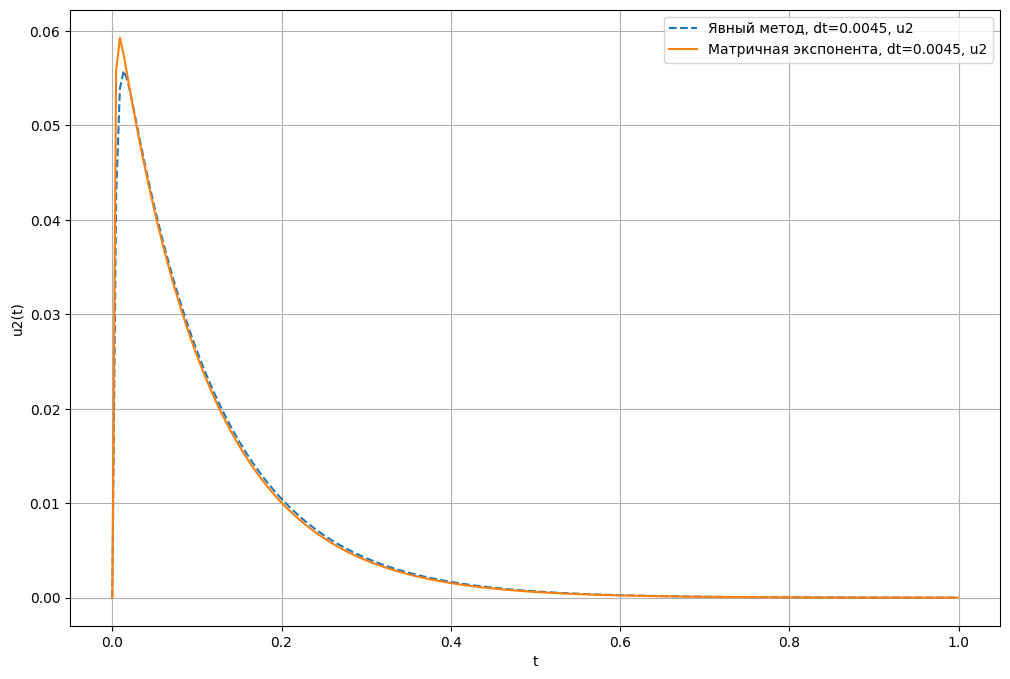

In [6]:
def euler_solve3(a, u0, T, dt):
    num_steps = int(T / dt)
    tt = np.arange(num_steps + 1) * dt
    y = np.zeros((num_steps + 1, len(u0)))
    y[0] = u0
    I = np.eye(len(u0))
    for i in range(num_steps):
        y[i + 1] = np.linalg.solve(I - dt * a, y[i])
    return tt, y

u0 = np.array([1, 0])
T = 1
dts = [0.01,0.004, 0.0045]

# Графики
for dt in dts:
    plt.figure(figsize=(12, 8))
    t, y = euler_solve3(A, u0, T, dt)
    ym = mat_exp_solve(A, u0, t)
    plt.plot(t, y[:, 0], '--', label=f'Явный метод (dt={dt}), u1')
    plt.plot(t, ym[:, 0], '-', label=f'Матричная экспонента (dt={dt}), u1')
    plt.xlabel('t')
    plt.ylabel('u1(t)')
    plt.legend()
    plt.grid(True)
    plt.show()
    plt.figure(figsize=(12, 8))
    plt.plot(t, y[:, 1], '--', label=f'Явный метод, dt={dt}, u2')
    plt.plot(t, ym[:, 1], '-', label=f'Матричная экспонента, dt={dt}, u2')
    plt.xlabel('t')
    plt.ylabel('u2(t)')
    plt.legend()
    plt.grid(True)
    plt.show()

Видим, что численное решение, полученное с помощью неявного метода Эйлера практически совпадает с точным решением, в отличие от явного метода Эйлера (при тех же значениях временного шага $dt$)

## **Задание 6**

Представив производную $\dfrac{du}{dt}$ в виде новой переменной $v(t)$ перейдём от диффура второго порядка к двумерной системе первого порядка

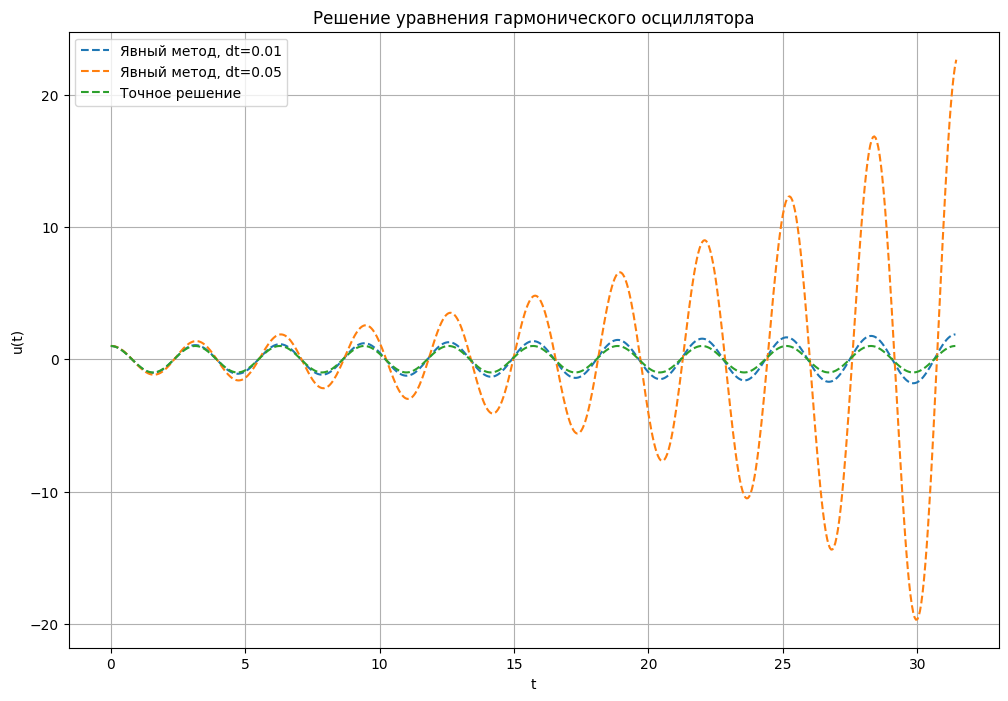

In [7]:
omega = 2  
T_period = 2 * np.pi / omega  

# Сами определим начальные условия
u0 = 1
v0 = 0
y0 = [u0, v0]

# Правая часть системы
def right(y):
    return np.array([y[1], -omega**2 * y[0]])

# Явный метод Эйлера
def euler_solve(f, y0, t, dt):
    ts = np.arange(t[0], t[1] + dt, dt)
    y = np.zeros((len(ts), len(y0)))

    # Начальное условие
    y[0] = y0

    for i in range(1, len(ts)):
        y[i] = y[i-1] + dt * np.array(f(y[i-1]))
    return ts, y

t = [0, 10 * T_period]
dts = [0.01, 0.05]  

plt.figure(figsize=(12, 8))

for dt in dts:
    ti, y = euler_solve(right, y0, t, dt)
    plt.plot(ti, y[:, 0], '--', label=f'Явный метод, dt={dt}')

# Точное решение
t_exact = np.linspace(0, 10 * T_period, 1000)
u_exact = u0 * np.cos(omega * t_exact)
plt.plot(t_exact, u_exact, '--', label='Точное решение')
plt.xlabel('t')
plt.ylabel('u(t)')
plt.title('Решение уравнения гармонического осциллятора')
plt.legend()
plt.grid(True)
plt.show()

Проверим ЗСЭ:

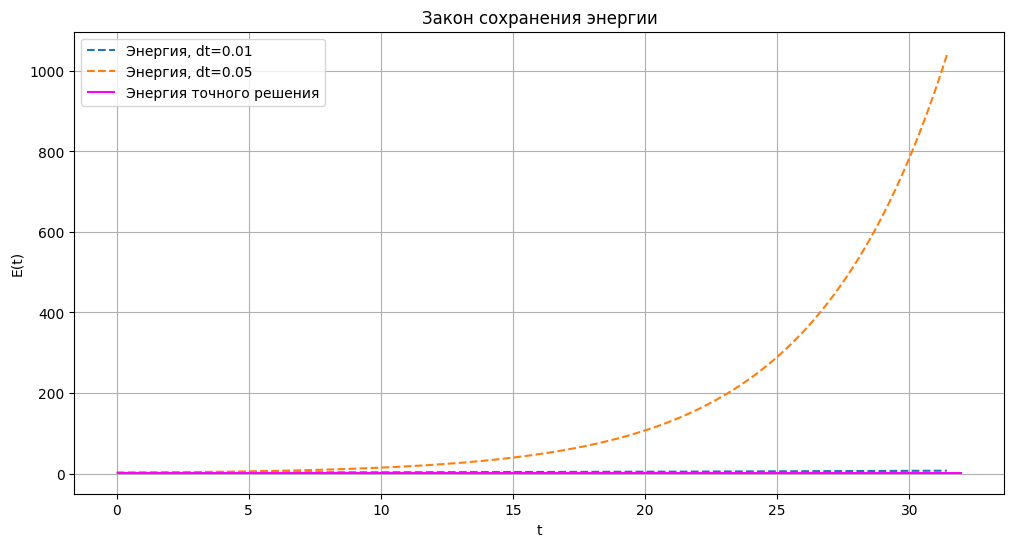

In [8]:
def E(y, omega):
    return y[:, 1]**2/2 + omega**2 * y[:, 0]**2/2

plt.figure(figsize=(12, 6))
for dt in dts:
    ti, y = euler_solve(right, y0, t, dt)
    en = E(y, omega)
    plt.plot(ti, en, '--', label=f'Энергия, dt={dt}')

plt.hlines(omega**2/2, 0, 32, label=f'Энергия точного решения', color='magenta')
plt.xlabel('t')
plt.ylabel('E(t)')
plt.title('Закон сохранения энергии')
plt.legend()
plt.grid(True)
plt.show()

Видим, что при большом шаге по времени происходит неконтролируемое нарастание энергии и ЗСЭ не выполняется

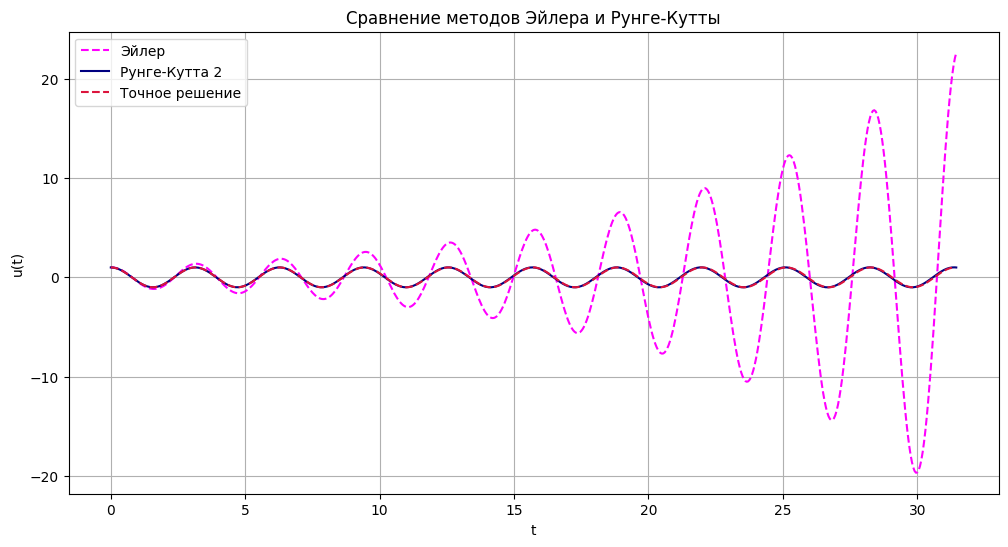

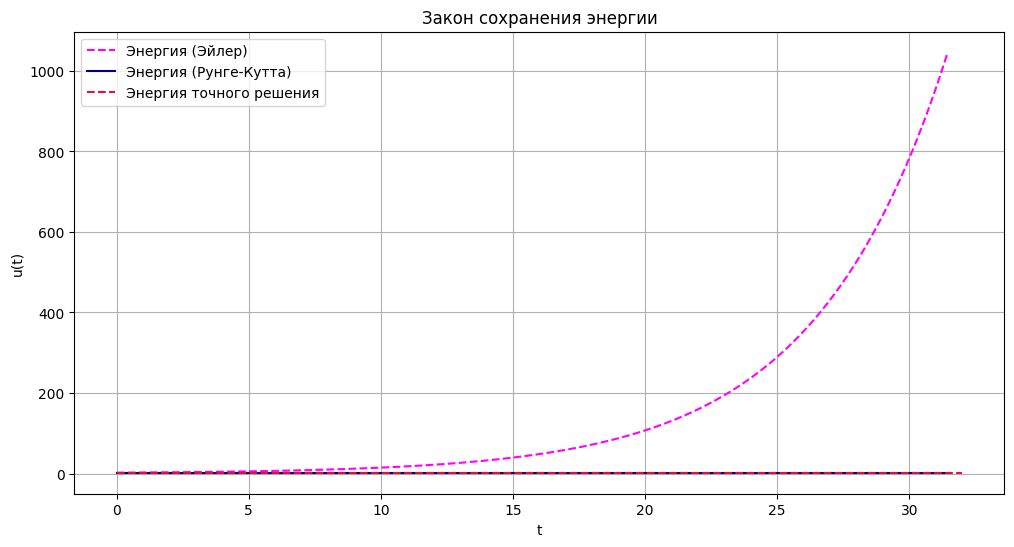

In [9]:
def rk_2_solve(f, y0, t_span, dt):
    t = np.arange(t_span[0], t_span[1] + dt, dt)
    y = np.zeros((len(t), len(y0)))

    # Начальные условия
    y[0] = y0

    for i in range(1, len(t)):

        # Не будем усложнять, пусть будет явный метод Рунге-Кутта
        k1 = np.array(f(y[i-1, :]))
        k2 = np.array(f(y[i-1, :] + dt * k1))

        y[i, :] = y[i-1, :] + dt * (k1 + k2) / 2
    return t, y

# Сравнение методов при фиксированном шаге по времени
dt = 0.05
t_euler, y_euler = euler_solve(right, y0, t, dt)
t_rk_2, y_rk_2 = rk_2_solve(right, y0, t, dt)

plt.figure(figsize=(12, 6))
plt.plot(t_euler, y_euler[:, 0], '--', label='Эйлер', color = 'magenta')
plt.plot(t_rk_2, y_rk_2[:, 0], label='Рунге-Кутта 2', color = 'navy')
plt.plot(t_exact, u_exact, '--', label='Точное решение', color = 'crimson')
plt.xlabel('t')
plt.ylabel('u(t)')
plt.title('Сравнение методов Эйлера и Рунге-Кутты')
plt.legend()
plt.grid(True)
plt.show()

# Проверка ЗСЭ
E_euler = E(y_euler, omega)
E_rk_2 = E(y_rk_2, omega)

plt.figure(figsize=(12, 6))
plt.plot(t_euler, E_euler, '--', label='Энергия (Эйлер)', color = 'magenta')
plt.plot(t_rk_2, E_rk_2, label='Энергия (Рунге-Кутта)', color = 'navy')
plt.hlines(omega**2/2, 0, 32, linestyles='--',label=f'Энергия точного решения', color='crimson')
plt.xlabel('t')
plt.ylabel('u(t)')
plt.title('Закон сохранения энергии')
plt.legend()
plt.grid(True)
plt.show()

Видим, что метод Рунге-Кутта практически идеально (насколько это позволяет судить график) совпадает с точным решением, в отличие от явного метода Эйлера. Как следствие, для метода Рунге-Кутта с хорошей точностью выполняется ЗСЭ.

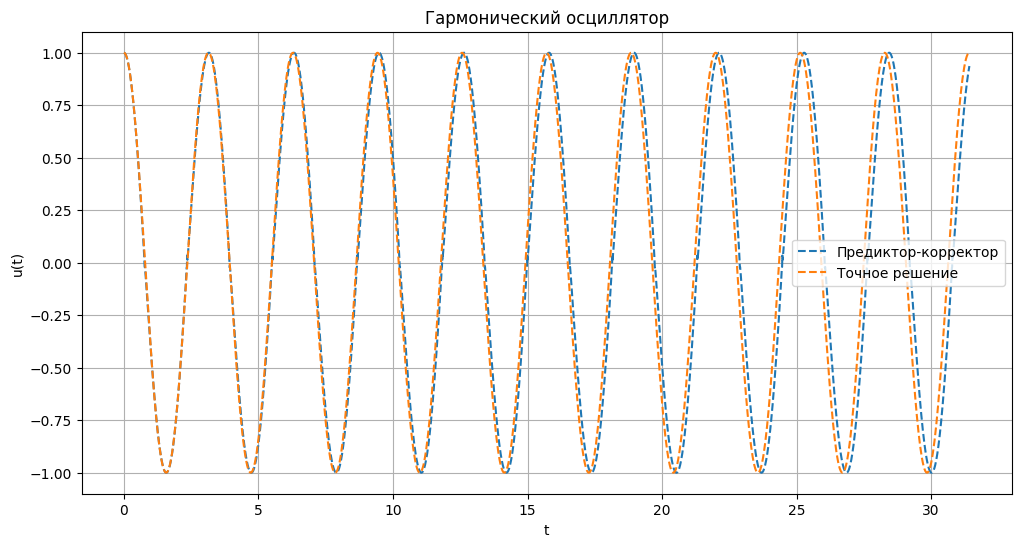

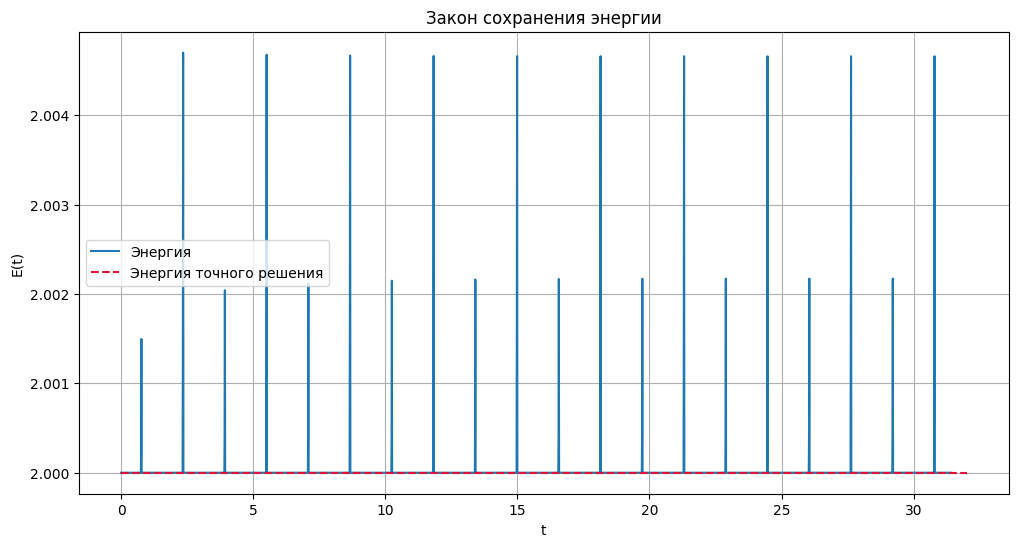

In [10]:
def pred_corr(t_span, dt):
    t = np.arange(t_span[0], t_span[1] + dt, dt)
    y = np.zeros((len(t), 2))
    y[0] = y0
    for i in range(1, len(t)):
        # Предиктор 
        y[i] = y[i-1] + [dt*y[i-1, 1], -omega**2 * y[i-1, 0]*dt]

        # Корректор 
        E = omega**2/2
        u_corr = np.sqrt(np.absolute(2 * E - y[i,1]**2))/omega * np.sign(y[i,0])
        y[i] = [u_corr,y[i,1]]
    return t, y

t_span = [0, 10*T_period]
dt = 0.01
t_pc, y_pc = pred_corr(t_span, dt)

# Графики
plt.figure(figsize=(12, 6))
plt.plot(t_pc, y_pc[:, 0], '--', label='Предиктор-корректор')
plt.plot(t_exact, u_exact, '--', label='Точное решение')
plt.xlabel('t')
plt.ylabel('u(t)')
plt.title('Гармонический осциллятор')
plt.legend()
plt.grid(True)
plt.show()


# Проверка ЗСЭ
E_pc = E(y_pc, omega)

plt.figure(figsize=(12, 6))
plt.plot(t_pc, E_pc, '-', label='Энергия')
plt.hlines(omega**2/2, 0, 32, color='crimson', linestyle='--', label='Энергия точного решения')
plt.xlabel('t')
plt.ylabel('E(t)')
plt.title('Закон сохранения энергии')
plt.legend()
plt.grid(True)
plt.show()


Видим, что, несмотря на то, что изначально кажется, что численное решение совпадает с точным, после достаточно большого числа колебаний заметно небольшое "убегание" точного решения вперёд относительно точного решения. Также на графике энергии видны периодические отклонения энергии численного решения от точного значения энергии (пусть и не слишком существенные - см. координаты оси энергии).

## **Задание 7**

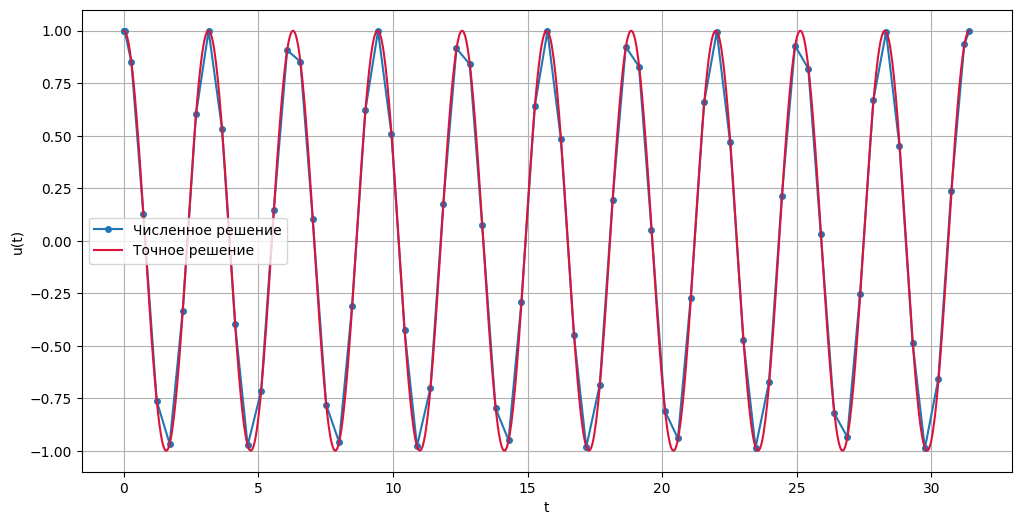

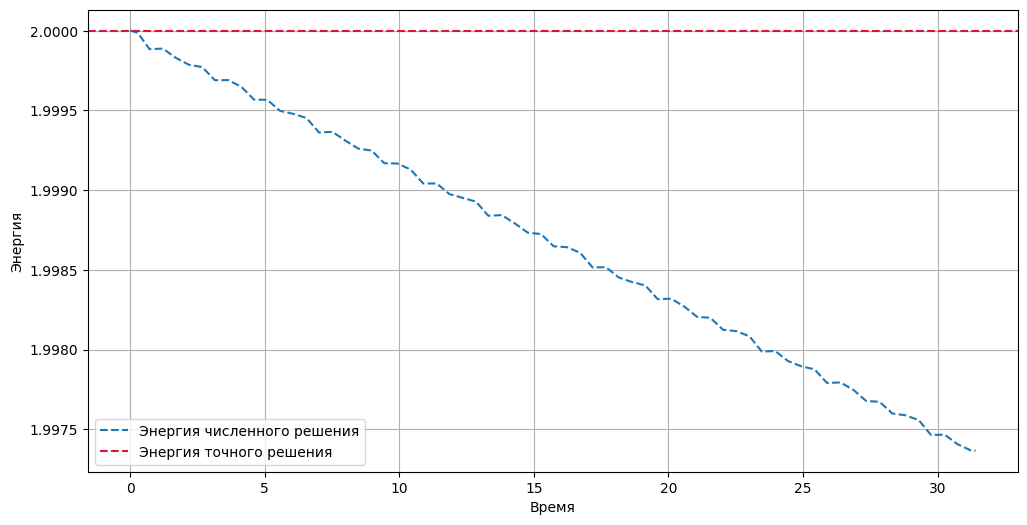

In [11]:
from scipy.integrate import solve_ivp
def right_w_t(t,y):
    return np.array([y[1], -omega**2 * y[0]])

sol = solve_ivp(right_w_t, t_span, y0)

# Точное решение
t_exact = np.linspace(t_span[0], t_span[1], 1000)
u_exact = y0[0] * np.cos(omega * t_exact)

# Визуализация
plt.figure(figsize=(12, 6))

plt.plot(sol.t, sol.y[0], 'o-', label='Численное решение', markersize=4)
plt.plot(t_exact, u_exact, '-', label='Точное решение', color = 'crimson')
plt.xlabel('t')
plt.ylabel('u(t)')
plt.legend()
plt.grid(True)
plt.show()

# Проверка ЗСЭ
plt.figure(figsize=(12, 6))
E = 0.5*sol.y[1]**2 + 0.5*omega**2*sol.y[0]**2
plt.plot(sol.t, E, '--', label=f'Энергия численного решения', markersize=3)
plt.axhline(0.5*omega**2*y0[0]**2, color='crimson', linestyle='--', label='Энергия точного решения')
plt.xlabel('Время')
plt.ylabel('Энергия')
plt.legend()
plt.grid(True)
plt.show()

Видим, что ЗСЭ для численного решения немного не выполняется, однако отклонение достаточно мало. К тому же изменяя точность поиска решения в аргументе функции можно добиться и более точных результатов.

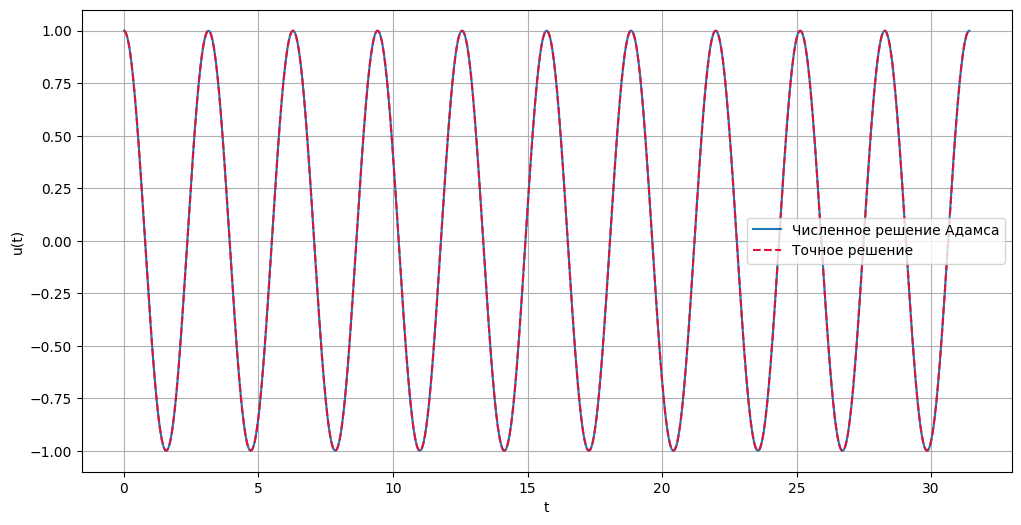

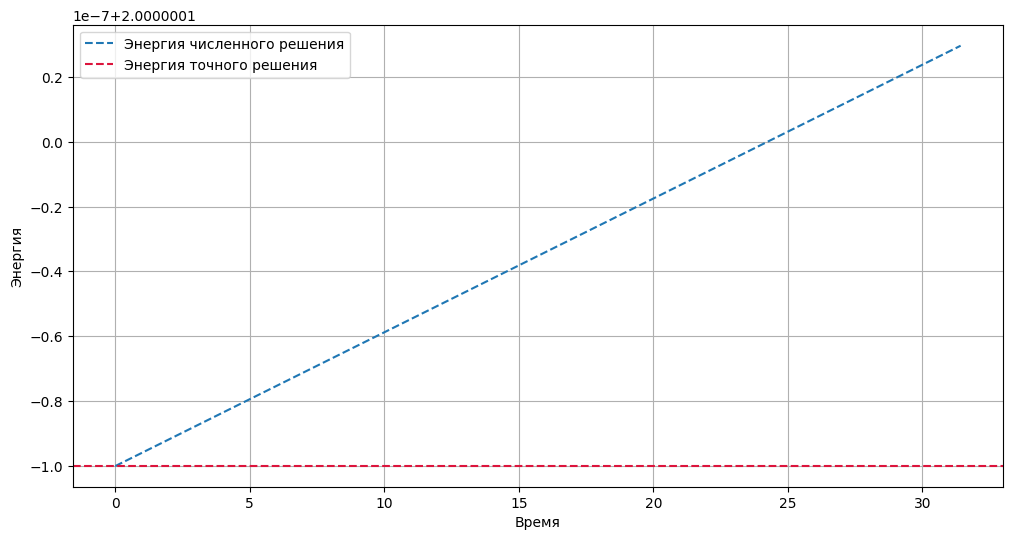

In [12]:
from scipy.linalg import solve


def adams(t_span, y0, tau):
    t = np.arange(t_span[0], t_span[1] + tau, tau)
    y = np.zeros((len(t), len(y0)))

    # Начальные условия
    y[0] = y0

    # Первые 3 точки по методу Рунге-Кутты
    for i in range(1,4):
        # Считаем коэффициенты k_i
        k1 = tau*right(y[i-1])
        k2 = tau*right(y[i-1] + k1/2)
        k3 = tau*right(y[i-1] + k2/2)
        k4 = tau*right(y[i-1] + k3)
        y[i] = y[i-1] + (k1 + 2*k2 + 2*k3 + k4)/6

    # Остальные значения по методу Адамса
    for i in range(4, len(t)):
        # Предиктор
        y[i] = y[i-1] + tau*(55*right(y[i-1]) - 59*right(y[i-2]) + 37*right(y[i-3]) - 9*right(y[i-4]))/24

        # Корректор
        y[i] = y[i-1] + tau*(9*right(y[i]) + 19*right(y[i-1]) - 5*right(y[i-2]) + right(y[i-3]))/24

    return t, y

sol = adams(t_span, y0, dt)

# Точное решение
t_exact = np.linspace(t_span[0], t_span[1], 1000)
u_exact = y0[0] * np.cos(omega * t_exact)

# Визуализация
plt.figure(figsize=(12, 6))

plt.plot(sol[0], sol[1][:, 0], '-', label='Численное решение Адамса', markersize=4)
plt.plot(t_exact, u_exact, '--', label='Точное решение', color = 'crimson')
plt.xlabel('t')
plt.ylabel('u(t)')
plt.legend()
plt.grid(True)
plt.show()

# Проверка ЗСЭ
plt.figure(figsize=(12, 6))
E = 0.5*sol[1][:, 1]**2 + 0.5*omega**2*sol[1][:,0]**2
plt.plot(sol[0], E, '--', label=f'Энергия численного решения', markersize=3)
plt.axhline(0.5*omega**2*y0[0]**2, color='crimson', linestyle='--', label='Энергия точного решения')
plt.xlabel('Время')
plt.ylabel('Энергия')
plt.legend()
plt.grid(True)
plt.show()

Видим, что численное решение, полученное методом Адамса хорошо описывает точное решение, а ЗСЭ с хорошей точностью выполняется (отклонение по энергии пренебрежимо мало).

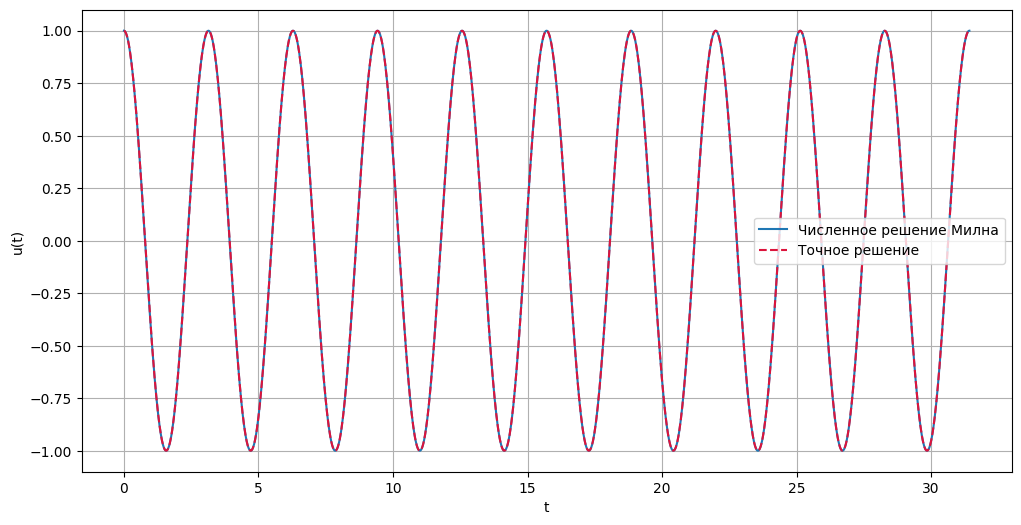

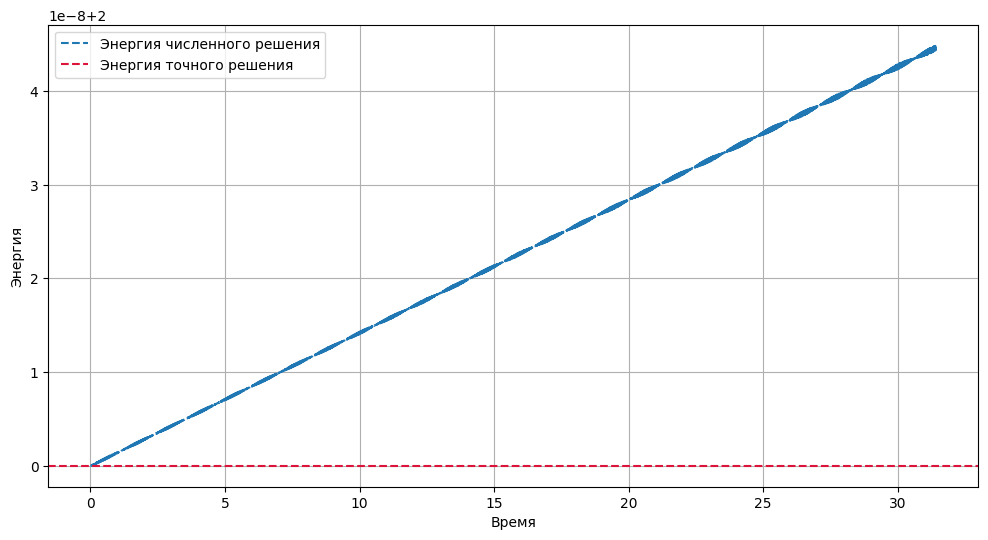

In [13]:
def milne(t_span, y0, tau):
    t = np.arange(t_span[0], t_span[1] + tau, tau)
    y = np.zeros((len(t), len(y0)))

    # Начальные условия
    y[0] = y0

    # Первые 3 точки по методу Рунге-Кутты (четвёртая - это начальное условие)
    for i in range(1,4):
        # Считаем коэффициенты k_i
        k1 = tau*right(y[i-1])
        k2 = tau*right(y[i-1] + k1/2)
        k3 = tau*right(y[i-1] + k2/2)
        k4 = tau*right(y[i-1] + k3)
        y[i] = y[i-1] + (k1 + 2*k2 + 2*k3 + k4)/6

    # Остальные значения по метода Милна
    for i in range(4, len(t)):
        # Предиктор
        y[i] = y[i-4] + 4*tau/3*(2*right(y[i-3]) - right(y[i-2]) + 2*right(y[i-1]))

        # Корректор
        y[i] = y[i-2] + tau/3*(right(y[i-2]) + 4*right(y[i-1]) + right(y[i]))

    return t, y

sol = milne(t_span, y0, dt)

# Точное решение
t_exact = np.linspace(t_span[0], t_span[1], 1000)
u_exact = y0[0] * np.cos(omega * t_exact)

# Визуализация
plt.figure(figsize=(12, 6))

plt.plot(sol[0], sol[1][:, 0], '-', label='Численное решение Милна', markersize=4)
plt.plot(t_exact, u_exact, '--', label='Точное решение', color = 'crimson')
plt.xlabel('t')
plt.ylabel('u(t)')
plt.legend()
plt.grid(True)
plt.show()

# Проверка ЗСЭ
plt.figure(figsize=(12, 6))
E = 0.5*sol[1][:, 1]**2 + 0.5*omega**2*sol[1][:,0]**2
plt.plot(sol[0], E, '--', label=f'Энергия численного решения', markersize=3)
plt.axhline(0.5*omega**2*y0[0]**2, color='crimson', linestyle='--', label='Энергия точного решения')
plt.xlabel('Время')
plt.ylabel('Энергия')
plt.legend()
plt.grid(True)
plt.show()

Аналогично, метода Милна хорошо работает в нашем случае, судя по цифрам даже на порядок точнее метода Адамса.

## **Задание 8**

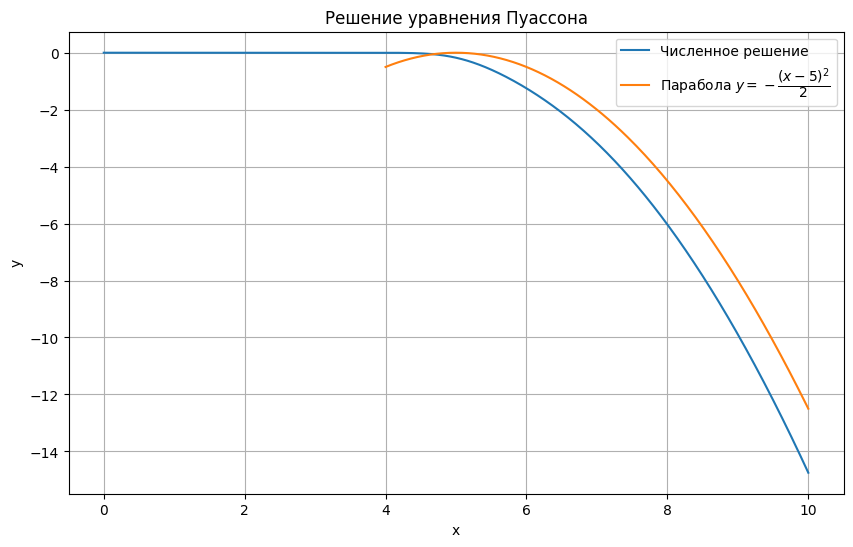

In [14]:
def solver(T, dx):
    num_steps = int(T / dx)
    xs = np.arange(num_steps + 1) * dx
    y = np.zeros(num_steps + 1)

    # Граничные условия
    y[0] = 0
    y[1] = 0

    for k in range(1, num_steps):
        # Используем аппроксимацию производной второго порядка
        y[k+1] = 2*y[k]-y[k-1]+dx**2*(np.exp(y[k])-(1+np.exp(-3*(k*dx-5)**2)))
    return xs, y

x, y = solver(10, 0.01)
plt.figure(figsize=(10,6))
plt.plot(x,y, label='Численное решение')
x_parab = np.linspace(4, 10, 200)
plt.plot(x_parab, -(x_parab-5)**2/2, label = r'Парабола $y = -\dfrac{(x-5)^2}{2}$')

plt.xlabel('x')
plt.ylabel('y')
plt.title('Решение уравнения Пуассона')
plt.legend()
plt.grid(True)
plt.show()

Теперь ищем аналитическое решение уравнения $$y''(x)=e^{y(x)}-1-e^{-3(x-5)^2}$$ с помощью разложения в ряд Тейлора: $$y(x)=y(0)+y'(0)x+\dfrac{1}{2}y''(0)x^2+\dfrac{1}{6}y'''(0)x^3+\cdots=\dfrac{1}{2}y''(0)x^2+\dfrac{1}{6}y'''(0)x^3+\cdots$$ Здесь уже учли граничные условия задачи. Найдём теперь значения второй и третьей производных в нуле, исходя из диффура: $$y''(0)=e^{y(0)}-1-e^{-75}=-e^{-75}\approx 0$$ $$y'''(0)=y'(x)e^{y(x)}+6(x-5)e^{-3(x-5)^2}=-30e^{-75} \approx 0$$ Видим, что значения практические нулевые. Это связано с показателем экспоненты, из вида которого понятно, что решение будет заметно ненулевое только при $x>5$. 

Тогда разложим в ряд Тейлора уже в точке $x = 5$, считая функцию и её первую производную всё ещё равными нулю (так как при $x<5$ решение практически константное и нулевое, а мы ищем решение в классе $C^2$): $$y''(5)=e^{y(5)}-1-e^{0}\approx-1$$ $$y(x)\approx-\dfrac{(x-5)^2}{2}$$

По графику выше видно, что мы немного промахнулись в выборе точки, начиная с которой функция перестаёт быть практически нулевой (мы взяли $x = 5$, а на деле чуть меньше пяти), однако по форме графиков видно, что решение действительно напоминает параболу $y = -\dfrac{(x-a)^2}{2}$, где $a$ - какое то число. 

## **Задание 9**

In [ ]:
from scipy.integrate import odeint
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
from ipywidgets import widgets
from time import sleep


def right_side(y, t, a, b, c):
    return (y[1], np.exp(y[0]) - a - np.exp(-b*(t-c)**2))

out1 = widgets.Output(layout={'width': '50%'})
out2 = widgets.Output(layout={'width': '50%'})
w_tmax = widgets.FloatSlider(description='tmax ', min=10, max=100, step=1, value=10)
w_n = widgets.IntSlider(description='Число шагов ', min=10, max=1000, step=1, value=200)
w_alpha = widgets.FloatSlider(description='alpha ', min=-100, max=100, step=0.1, value=1)
w_betta = widgets.FloatSlider(description='betta ', min=-100, max=100, step=0.1, value=3)
w_gamma = widgets.FloatSlider(description='gamma ', min=-100, max=100, step=0.1, value=5)
w_q = widgets.FloatSlider(description='q ', min=-100, max=100, step=0.1, value=0)
w_r = widgets.FloatSlider(description='r ', min=-100, max=100, step=0.1, value=0)
w_button = widgets.Button(description='Запустить', button_style='primary')

def main(*args):
    tmax = w_tmax.value
    n = w_n.value
    alpha = w_alpha.value
    betta = w_betta.value
    gamma = w_gamma.value
    q = w_q.value
    r = w_r.value
    t = np.linspace(0, tmax, n)
    y0 = (q, r) # начальные условия
    y = odeint(right_side, y0, t, args=(alpha, betta, gamma))
    with out2:
        clear_output(wait=True)
        fig = plt.figure(figsize=(7, 7))
        ax = fig.add_subplot(111)
        ax.plot(y[:,0],y[:,1], '--', lw=2)
        plt.xlabel("y")
        plt.xlabel("y'")
        plt.title("Фазовый портрет")
        plt.show()
        
w_button.on_click(main)

display(widgets.HBox([out1, out2]))
with out1:
    display(w_tmax,
            w_n,
            w_alpha,
            w_betta,
            w_gamma,
            w_q,
            w_r,
            w_button,)

Сама анимация странно себя ведёт: всё время появляются разные слайдеры (и то не все). Единственное, что я поменял - это формулу правой части, так что видимо это косяк кода в "Физическом моделировании" (в том файле тоже разные слайдеры появляются каждый раз).

Тем не менее фазовый портрет соответствует действительности.

In [12]:
def run(*args):
    delay = w_delay.value
    tmax = w_tmax.value
    n = w_n.value
    alpha = w_alpha.value
    betta = w_betta.value
    gamma = w_gamma.value
    q = w_q.value
    r = w_r.value
    t = np.linspace(0, w_tmax.value, n)
    y0 = (q, r) # начальные условия
    y = odeint(right_side, y0, t, args=(alpha, betta, gamma))
    with out4:
        for i in range(0, len(y), len(y)//200):
            clear_output(wait=True)
            plt.figure(figsize=(7, 7))
            plt.title('Фазовый портрет')
            plt.xlim((np.min(y[:, 0])-0.1, np.max(y[:, 0]+0.1)))
            plt.ylim((np.min(y[:, 1])-0.1, np.max(y[:, 1]+0.1)))
            plt.plot(y[:i, 0], y[:i, 1], color='black', lw=2)
            plt.xlabel('x')
            plt.ylabel('y')
            plt.show()
            sleep(delay)


out3 = widgets.Output(layout={'width': '50%'})
out4 = widgets.Output(layout={'width': '50%'})
w_delay = widgets.FloatSlider(description='Задержка ', min=0, max=1, step=0.01, value=0.01)
w_button = widgets.Button(description='Запустить', button_style='primary')
w_button.on_click(run)
display(widgets.HBox([out3, out4]))
with out3:
    display(w_delay,
            w_button)

Анимировали фазовый портрет. Действительно, сначала график долго "сидит" в начале координат (это константная часть нашего решения - которая до $\approx 5$ секунд), а потом съезжает в отрицательную область.

По фазовому портрету вообще не удобно подбирать параметры начальных условий так, чтобы удовлетворить условию $\varphi(10) = 0$, но если вместо фазового портрета рисовать зависимость $\varphi(t)$, то уже можно ползунками искать нужное значение параметра

In [22]:
def right_side(y, t, a, b, c):
    return (y[1], np.exp(y[0]) - a - np.exp(-b*(t-c)**2))

out1 = widgets.Output(layout={'width': '50%'})
out2 = widgets.Output(layout={'width': '50%'})
w_tmax = widgets.FloatSlider(description='tmax ', min=10, max=100, step=1, value=10)
w_n = widgets.IntSlider(description='Число шагов ', min=10, max=1000, step=1, value=200)
w_alpha = widgets.FloatSlider(description='alpha ', min=-100, max=100, step=0.1, value=1)
w_betta = widgets.FloatSlider(description='betta ', min=-100, max=100, step=0.1, value=3)
w_gamma = widgets.FloatSlider(description='gamma ', min=-100, max=100, step=0.1, value=5)
w_q = widgets.FloatSlider(description='q ', min=-100, max=100, step=0.1, value=0)
w_r = widgets.FloatSlider(description='r ', min=-10, max=10, step=0.1, value=0)
w_button = widgets.Button(description='Запустить', button_style='primary')

def main(*args):
    tmax = w_tmax.value
    n = w_n.value
    alpha = w_alpha.value
    betta = w_betta.value
    gamma = w_gamma.value
    q = w_q.value
    r = w_r.value
    t = np.linspace(0, tmax, n)
    y0 = (q, r) # начальные условия
    y = odeint(right_side, y0, t, args=(alpha, betta, gamma))
    with out2:
        clear_output(wait=True)
        fig = plt.figure(figsize=(7, 7))
        ax = fig.add_subplot(111)
        ax.plot(t, y[:,0], '--', lw=2)
        plt.xlabel("y")
        plt.xlabel("y'")
        plt.title("График функции от времени")
        plt.show()

        
w_button.on_click(main)

display(widgets.HBox([out1, out2]))
with out1:
    display(w_tmax,
            w_n,
            w_alpha,
            w_betta,
            w_gamma,
            w_q,
            w_r,
            w_button,)

Видим, что с помощью изменения производной в нуле не получится добиться искомого значения функции. Для этого дополнительно также нужно менять и значение самой функции в нуле.

## **Задание 10**

Строим фазовый портрет

In [ ]:
def right_side(y, t, omega, beta):
    return y[1], -omega**2*y[0]-beta*y[0]**3

out1 = widgets.Output(layout={'width': '50%'})
out2 = widgets.Output(layout={'width': '50%'})
w_tmax = widgets.FloatSlider(description='tmax ', min=10, max=100, step=1, value=10)
w_n = widgets.IntSlider(description='Число шагов ', min=10, max=1000, step=1, value=200)
w_alpha = widgets.FloatSlider(description='alpha ', min=-100, max=100, step=0.1, value=1)
w_betta = widgets.FloatSlider(description='betta ', min=-100, max=100, step=0.1, value=1)
w_q = widgets.FloatSlider(description='q ', min=-100, max=100, step=0.1, value=1)
w_r = widgets.FloatSlider(description='r ', min=-100, max=100, step=0.1, value=1)
w_button = widgets.Button(description='Запустить', button_style='primary')

def main(*args):
    tmax = w_tmax.value
    n = w_n.value
    alpha = w_alpha.value
    betta = w_betta.value
    q = w_q.value
    r = w_r.value
    t = np.linspace(0, tmax, n)
    y0 = (q, r) # начальные условия
    y = odeint(right_side, y0, t, args=(alpha, betta))
    with out2:
        clear_output(wait=True)
        fig = plt.figure(figsize=(7, 7))
        ax = fig.add_subplot(111)
        ax.plot(y[:,0],y[:,1], '--', lw=2)
        plt.xlabel("y")
        plt.ylabel("y'")
        plt.title("Фазовый портрет")
        plt.show()
        
w_button.on_click(main)

display(widgets.HBox([out1, out2]))
with out1:
    display(w_tmax,
            w_n,
            w_alpha,
            w_betta,
            w_q,
            w_r,
            w_button,)

Анимируем фазовый портрет

In [29]:
def run(*args):
    delay = w_delay.value
    tmax = w_tmax.value
    n = w_n.value
    alpha = w_alpha.value
    betta = w_betta.value
    q = w_q.value
    r = w_r.value
    t = np.linspace(0, w_tmax.value, n)
    y0 = (q, r) # начальные условия
    y = odeint(right_side, y0, t, args=(alpha, betta))
    with out4:
        for i in range(0, len(y), len(y)//200):
            clear_output(wait=True)
            plt.figure(figsize=(7, 7))
            plt.title('Фазовый портрет')
            plt.xlim((np.min(y[:, 0])-0.1, np.max(y[:, 0]+0.1)))
            plt.ylim((np.min(y[:, 1])-0.1, np.max(y[:, 1]+0.1)))
            plt.plot(y[:i, 0], y[:i, 1], color='black', lw=2)
            plt.xlabel('y')
            plt.ylabel("y'")
            plt.show()
            sleep(delay)


out3 = widgets.Output(layout={'width': '50%'})
out4 = widgets.Output(layout={'width': '50%'})
w_delay = widgets.FloatSlider(description='Задержка ', min=0, max=1, step=0.01, value=0.01)
w_button = widgets.Button(description='Запустить', button_style='primary')
w_button.on_click(run)
display(widgets.HBox([out3, out4]))
with out3:
    display(w_delay,
            w_button)

Строим зависимость координаты от времени

In [ ]:
out1 = widgets.Output(layout={'width': '50%'})
out2 = widgets.Output(layout={'width': '50%'})
w_tmax = widgets.FloatSlider(description='tmax ', min=10, max=100, step=1, value=10)
w_n = widgets.IntSlider(description='Число шагов ', min=10, max=1000, step=1, value=200)
w_alpha = widgets.FloatSlider(description='alpha ', min=-100, max=100, step=0.1, value=1)
w_betta = widgets.FloatSlider(description='betta ', min=-100, max=100, step=0.1, value=1)
w_q = widgets.FloatSlider(description='q ', min=-100, max=100, step=0.1, value=1)
w_r = widgets.FloatSlider(description='r ', min=-10, max=10, step=0.1, value=1)
w_button = widgets.Button(description='Запустить', button_style='primary')

def main(*args):
    tmax = w_tmax.value
    n = w_n.value
    alpha = w_alpha.value
    betta = w_betta.value
    q = w_q.value
    r = w_r.value
    t = np.linspace(0, tmax, n)
    y0 = (q, r) # начальные условия
    y = odeint(right_side, y0, t, args=(alpha, betta))
    with out2:
        clear_output(wait=True)
        fig = plt.figure(figsize=(7, 7))
        ax = fig.add_subplot(111)
        ax.plot(t, y[:,0], '--', lw=2)
        plt.xlabel("t")
        plt.xlabel("y")
        plt.title("График функции от времени")
        plt.show()

        
w_button.on_click(main)

display(widgets.HBox([out1, out2]))
with out1:
    display(w_tmax,
            w_n,
            w_alpha,
            w_betta,
            w_q,
            w_r,
            w_button,)

Строим зависимость производной функции от времени

In [ ]:
out1 = widgets.Output(layout={'width': '50%'})
out2 = widgets.Output(layout={'width': '50%'})
w_tmax = widgets.FloatSlider(description='tmax ', min=10, max=100, step=1, value=10)
w_n = widgets.IntSlider(description='Число шагов ', min=10, max=1000, step=1, value=200)
w_alpha = widgets.FloatSlider(description='alpha ', min=-100, max=100, step=0.1, value=1)
w_betta = widgets.FloatSlider(description='betta ', min=-100, max=100, step=0.1, value=1)
w_q = widgets.FloatSlider(description='q ', min=-100, max=100, step=0.1, value=1)
w_r = widgets.FloatSlider(description='r ', min=-10, max=10, step=0.1, value=1)
w_button = widgets.Button(description='Запустить', button_style='primary')

def main(*args):
    tmax = w_tmax.value
    n = w_n.value
    alpha = w_alpha.value
    betta = w_betta.value
    q = w_q.value
    r = w_r.value
    t = np.linspace(0, tmax, n)
    y0 = (q, r) # начальные условия
    y = odeint(right_side, y0, t, args=(alpha, betta))
    with out2:
        clear_output(wait=True)
        fig = plt.figure(figsize=(7, 7))
        ax = fig.add_subplot(111)
        ax.plot(t, y[:,1], '--', lw=2)
        plt.xlabel("t")
        plt.xlabel("y'")
        plt.title("График производной функции от времени")
        plt.show()

        
w_button.on_click(main)

display(widgets.HBox([out1, out2]))
with out1:
    display(w_tmax,
            w_n,
            w_alpha,
            w_betta,
            w_q,
            w_r,
            w_button,)